This notebook contains test cases for create_image_collection, add_image, delete_image, delete_image_collection, build_overviews, build_footprint and calculate_statistics

In [1]:
import os
import glob
import json
import time

<h4> Setup Environmental Variables

In [2]:
import arcgis
from arcgis.gis import GIS

gis = GIS("https://pythonapi.playground.esri.com/portal", "arcgis_python", "amazing_arcgis_123")
gis

GIS @ https://pythonapi.playground.esri.com/portal version:7.1

In [3]:
arcgis.env.verbose=True

In [4]:
from arcgis.raster import analytics
isSupport = analytics.is_supported(gis)

if isSupport:
    print("Your enterprise gis supports orthomapping service")
else:
    print("Your enterprise gis does not support orthomapping service")
    exit()

Your enterprise gis supports orthomapping service


<h4> Create Folder

In [5]:
def currentTime():
    return time.strftime("%Y%m%d%H%M%S", time.localtime())
prj_folder_name = "omProject" + currentTime()
gis.content.create_folder(folder=prj_folder_name, owner=gis.users.me.username)
prj_folder_name

'omProject20191017185208'

In [6]:
# Add Images and Create Image Collection
username = gis.users.me.username
imageItemList = []
itemPropTemplate = {"type": "Image"}
imageList = ["../orthomapping/BU/YUN_0040.JPG", "../orthomapping/BU/YUN_0045.JPG","../orthomapping/BU/YUN_0079.JPG"]
for imageFullPath in imageList:
    imageName = imageFullPath[imageFullPath.rfind("\\")+1:]
    itemPropTemplate["title"] = imageName
    itemPropTemplate["tags"] = imageName
    itemPropTemplate["description"] = imageName

    imageItem = gis.content.add(item_properties=itemPropTemplate, data=imageFullPath,
                                owner=username, folder=prj_folder_name)
    imageItemList.append(imageItem)

../orthomapping/BU/YUN_0040.JPG
../orthomapping/BU/YUN_0045.JPG
../orthomapping/BU/YUN_0079.JPG


In [7]:
sw_raster_type_params = {"gps": [['YUN_0040.JPG', 34.0069887, -117.09279029999999],
  ['YUN_0045.JPG', 34.007113099722226, -117.09450929972222],['YUN_0079.JPG', 34.0066113, -117.09360669972222],],
"cameraProperties":{"maker":"Yuneec","model":"E90","focallength":8,"columns":5472,"rows":3648,"pixelsize":0.0024},
"isAltitudeFlightHeight":"false",
"averagezdem": {"url": "https://rais.dev.geocloud.com/arcgis/rest/services/Hosted/WorldSRTM90m/ImageServer"}}

In [8]:
from arcgis.raster.analytics import create_image_collection, add_image, delete_image, delete_image_collection
from arcgis.raster.analytics import build_footprints, build_overview, calculate_statistics

<h3> Sync

<h4> Create Image Collection

Submitted.
Executing...
CreateImageCollection GP Job: j710921b709aa48368e75f9abcc4c0ad4 finished successfully.


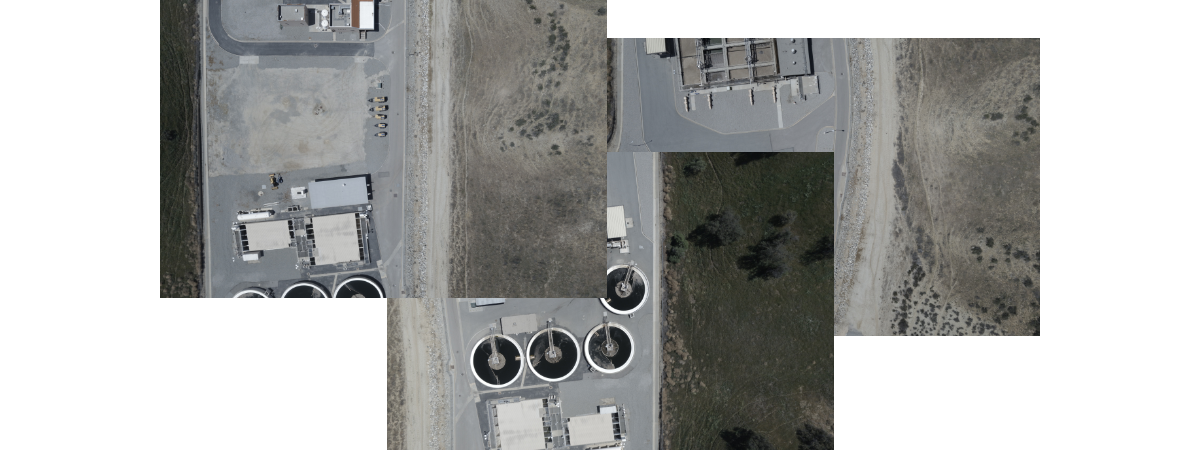

In [9]:
#For Sync Jobs of Build Footprints, Build Overviews and Calculate Statistics
image_collection_name = "imgcollect" + currentTime()
image_collection = create_image_collection(image_collection=image_collection_name,
                                           input_rasters=imageItemList,
                                           raster_type_name="UAV/UAS",
                                           raster_type_params=sw_raster_type_params,
                                           out_sr=32632,
                                           gis=gis,
                                           folder=prj_folder_name)
image_collection.layers[0]

<h4> Delete Image

In [10]:
delete_op = delete_image(image_collection=image_collection, 
                         where="OBJECTID=1",
                         gis=gis)
delete_op

Submitted.
Executing...
DeleteImage GP Job: j04666842053e40809d9c641d2f79797d finished successfully.

'https://pythonapi.playground.esri.com/ra/rest/services/Hosted/imgcollect20191017185251/ImageServer'

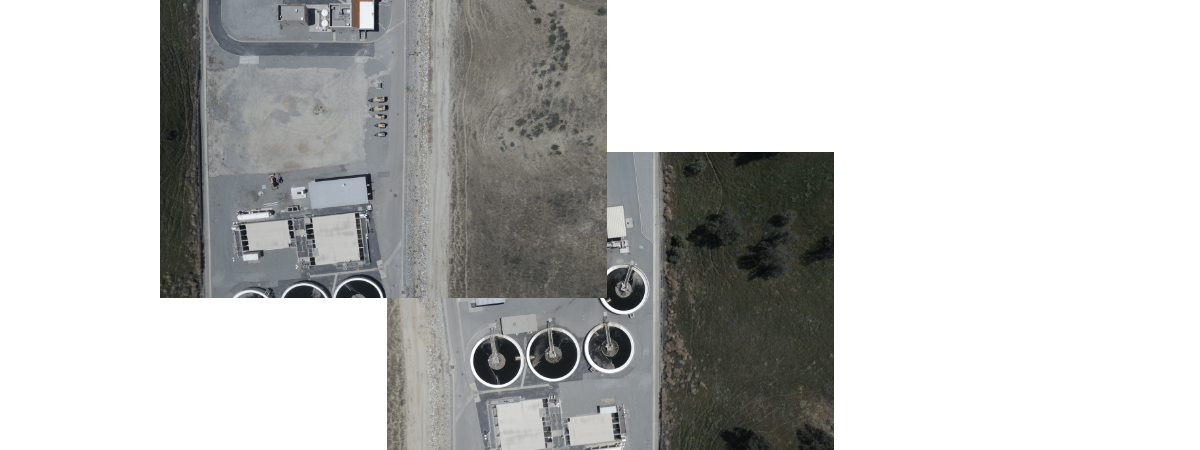

In [11]:
image_collection.layers[0]

<h4> Build Footprints Radiometry computation_method

In [12]:
build_footprint_1 = arcgis.raster.analytics.build_footprints(image_collection=image_collection,
                                                             computation_method='RADIOMETRY',
                                                             context={"minValue":"1","maxValue":"255","numVertices":"4", "shrinkDistance":"0","maintainEdge":"NO_MAINTAIN_EDGES", "skipDerivedImages":"SKIP_DERIVED_IMAGES","updateBoundary":"UPDATE_BOUNDARY","requestSize":"2000","minRegionSize":"100", "simplification":"NONE","maxSliverSize":"20","minThinnessRatio":"0.05"},
                                                             gis=gis)
build_footprint_1

Submitted.
Executing...
BuildFootprints GP Job: jb2235c0c098f412a95dea8f55c46f737 finished successfully.


'https://pythonapi.playground.esri.com/ra/rest/services/Hosted/imgcollect20191017185251/ImageServer'

<h4> Build Overviews

In [13]:
# build_overview_1 = arcgis.raster.analytics.build_overview(image_collection=image_collection,
#                                                           cell_size=10,
#                                                           gis=gis)

# build_overview_1

<h4> Calculate Statistics

In [14]:
calculate_statistics_1 = arcgis.raster.analytics.calculate_statistics(image_collection=image_collection, 
                                                                      skip_factors={"x":1,"y":1},
                                                                      gis=gis
                                                                      )
calculate_statistics_1

Submitted.
Executing...
CalculateStatistics GP Job: j9632a522d1b441d787c0b0c4017da042 finished successfully.

'https://pythonapi.playground.esri.com/ra/rest/services/Hosted/imgcollect20191017185251/ImageServer'

<h4> Add Image

In [15]:
add_raster = gis.content.search("YUN_0040")[0]

In [16]:
sw_raster_type_params = {"gps": [['YUN_0040.JPG', 34.0069887, -117.09279029999999]],
"cameraProperties":{"maker":"Yuneec","model":"E90","focallength":8,"columns":5472,"rows":3648,"pixelsize":0.0024},
"isAltitudeFlightHeight":"false",
"averagezdem": {"url": "https://rais.dev.geocloud.com/arcgis/rest/services/Hosted/WorldSRTM90m/ImageServer"}}

In [17]:
add_op = add_image(image_collection=image_collection, 
                   input_rasters=[add_raster], 
                   raster_type_name="UAV/UAS", 
                   raster_type_params=sw_raster_type_params
                  )
add_op

Submitted.
Executing...
AddImage GP Job: j79432da95f7c4564a9439d668d192aba finished successfully.

'https://pythonapi.playground.esri.com/ra/rest/services/Hosted/imgcollect20191017185251/ImageServer'

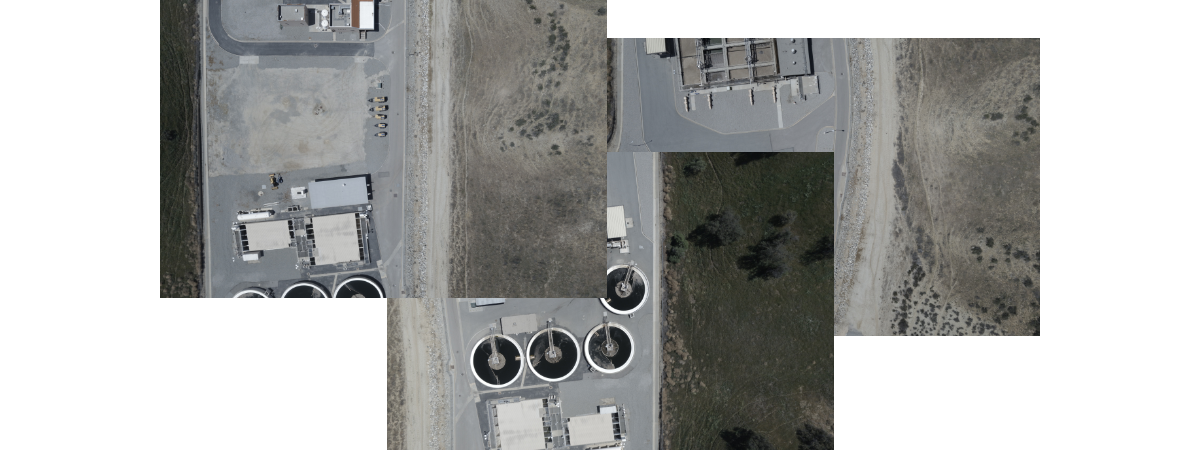

In [18]:
image_collection.layers[0]

<h4> Delete Image Collection

In [19]:
delete_image_collection(image_collection=image_collection)

DeleteImageCollection GP Job: j606d7b76a4784bdc8e5e25ae53315a6f finished successfully.

True

<h3> Async

Submitted.
Executing...
CreateImageCollection GP Job: jb630bb586cf74a62bd19e0e4c872be19 finished successfully.


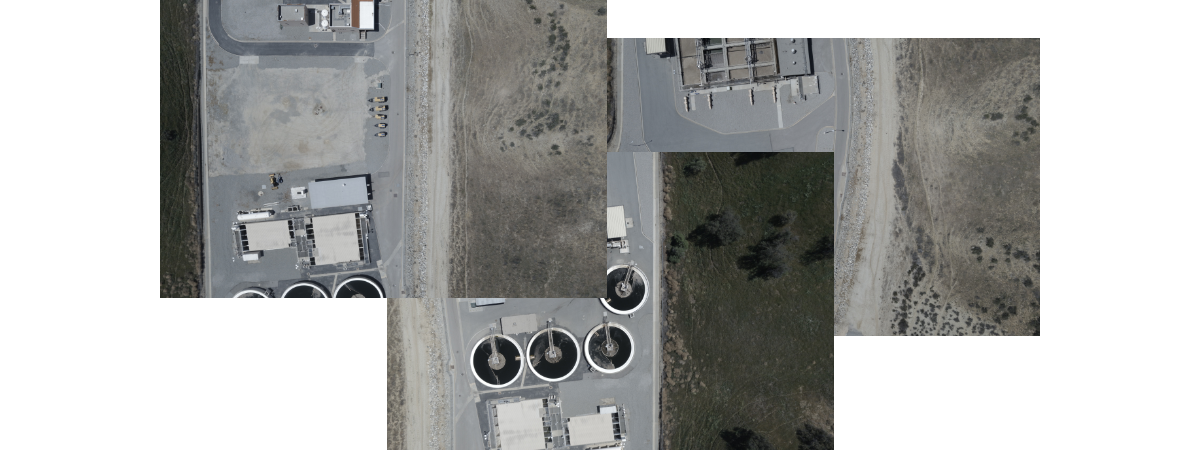

In [20]:
#For Async Jobs of Build Footprints, Build Overviews and Calculate Statistics
image_collection_name = "imgcollect" + currentTime()
image_collection_1 = create_image_collection(image_collection=image_collection_name,
                                             input_rasters=imageItemList,
                                             raster_type_name="UAV/UAS",
                                             raster_type_params=sw_raster_type_params,
                                             out_sr=32632,
                                             gis=gis,
                                             future=True,
                                             folder=prj_folder_name)
image_collection_1.result().layers[0]

<h4> Delete Image

In [21]:
delete_op = delete_image(image_collection=image_collection_1.result(), 
                         where="OBJECTID=1",
                         gis=gis,
                         future=True)
delete_op.result()

Submitted.
Executing...
DeleteImage GP Job: jf053228ca1d34423994a2ff9770bf7d8 finished successfully.

'https://pythonapi.playground.esri.com/ra/rest/services/Hosted/imgcollect20191017185913/ImageServer'

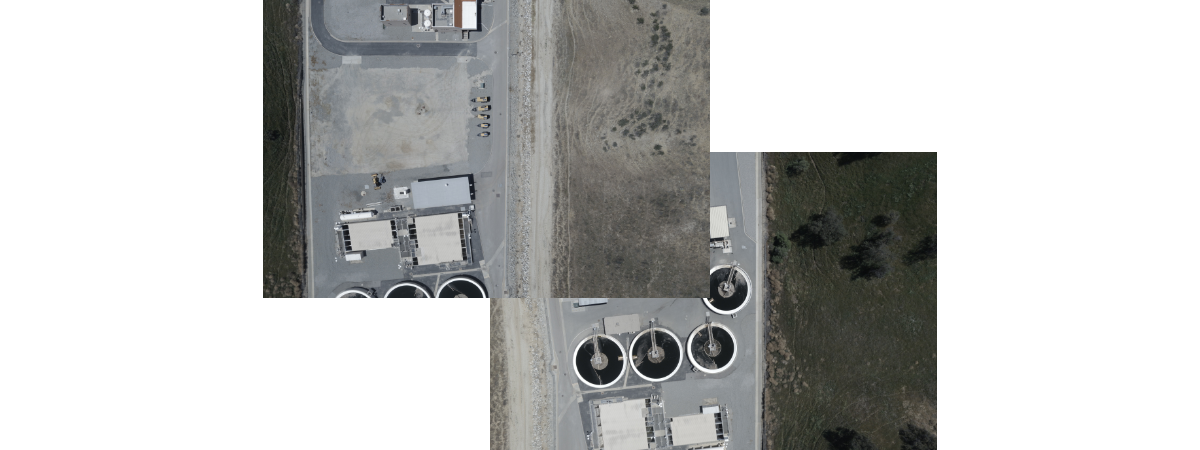

In [22]:
image_collection_1.result().layers[0]

<h4> Build Footprints GEOMETRY computation_method

In [23]:
build_footprint_2 = arcgis.raster.analytics.build_footprints(image_collection=image_collection_1.result(),
                                                             computation_method='GEOMETRY',
                                                             gis=gis,
                                                             future=True
                                                            )
build_footprint_2.result()

Submitted.
Executing...
BuildFootprints GP Job: je35b03906b2f43e7a1d5638914941134 finished successfully.

'https://pythonapi.playground.esri.com/ra/rest/services/Hosted/imgcollect20191017185913/ImageServer'

<h4> Build Overviews

In [24]:
# Fails in 
# build_overview_2 = arcgis.raster.analytics.build_overview(image_collection=image_collection_1.result(),
#                                                           cell_size=5,
#                                                           gis=gis,
#                                                           future=True
#                                                          )

# build_overview_2.result()

<h4> Calculate Statistics

In [25]:
calculate_statistics_2 = arcgis.raster.analytics.calculate_statistics(image_collection=image_collection_1.result(), 
                                                                      skip_factors={"x":5,"y":5},
                                                                      gis=gis,
                                                                      future=True
                                                                      )
calculate_statistics_2.result()

Submitted.
Executing...
CalculateStatistics GP Job: j3334eb4b97bf43a5923dad503822f945 finished successfully.

'https://pythonapi.playground.esri.com/ra/rest/services/Hosted/imgcollect20191017185913/ImageServer'

<h4> Add Image

In [26]:
add_raster = gis.content.search("YUN_0040")[0]

In [27]:
sw_raster_type_params = {"gps": [['YUN_0040.JPG', 34.0069887, -117.09279029999999]],
"cameraProperties":{"maker":"Yuneec","model":"E90","focallength":8,"columns":5472,"rows":3648,"pixelsize":0.0024},
"isAltitudeFlightHeight":"false",
"averagezdem": {"url": "https://rais.dev.geocloud.com/arcgis/rest/services/Hosted/WorldSRTM90m/ImageServer"}}

In [28]:
add_op = add_image(image_collection=image_collection_1.result(), 
                   input_rasters=[add_raster], 
                   raster_type_name="UAV/UAS", 
                   raster_type_params=sw_raster_type_params,
                   gis=gis,
                   future=True
                  )
add_op.result()

Submitted.
Executing...
AddImage GP Job: jdb0b43081cb8433998e28581050ad85f finished successfully.

'https://pythonapi.playground.esri.com/ra/rest/services/Hosted/imgcollect20191017185913/ImageServer'

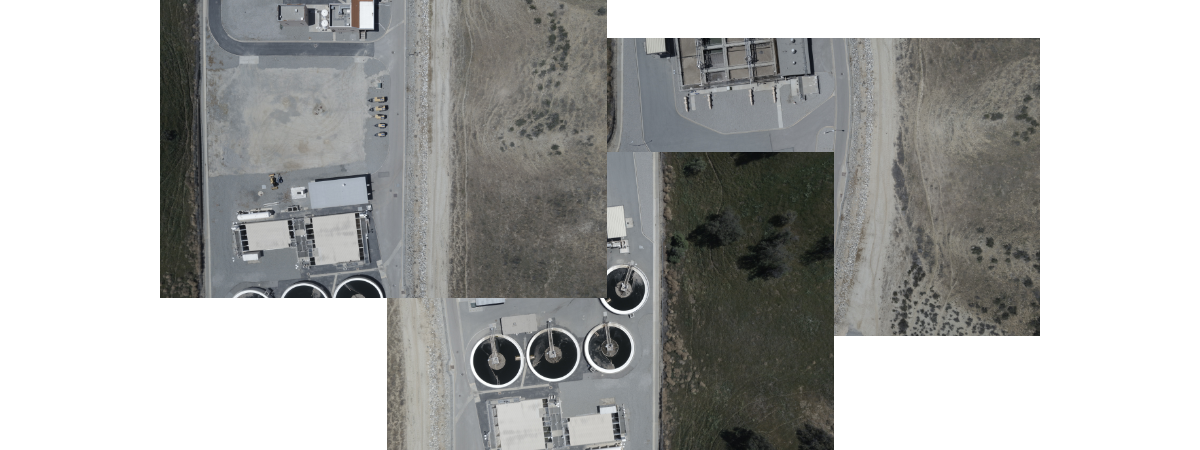

In [29]:
image_collection_1.result().layers[0]

<h4> Delete Image Collection

In [30]:
del_img_coll = delete_image_collection(image_collection=image_collection_1.result(),
                                       future=True)
del_img_coll.result()

DeleteImageCollection GP Job: j629a4f9c1ca4485d9ab340515cf9c0a6 finished successfully.

True

<h4> Clean Up

In [31]:
for item in imageItemList:
    print(item, " delete status: " + str(item.delete()))

<Item title:"../orthomapping/BU/YUN_0040.JPG" type:Image owner:arcgis_python>  delete status: True
<Item title:"../orthomapping/BU/YUN_0045.JPG" type:Image owner:arcgis_python>  delete status: True
<Item title:"../orthomapping/BU/YUN_0079.JPG" type:Image owner:arcgis_python>  delete status: True


In [32]:
gis.content.delete_folder(prj_folder_name)

True